# Clasificador Random Forest — Predicción de Parkinson

**Objetivo:** construir un modelo de clasificación (Random Forest) que, a partir de 32 variables clínicas
(edad, consumo de alcohol, calidad del sueño, colesterol, etc.), prediga si un paciente tiene diagnóstico
de Parkinson (`Diagnosis`).

**Datos:** `parkinsons_disease_data.csv`
- **X (features):** columnas `Age` (B) hasta `Constipation` (AG) → 32 variables clínicas
- **Y (etiqueta):** columna `Diagnosis` (AH) → 0 = No Parkinson, 1 = Parkinson


## 1. Importar librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)

%matplotlib inline


## 2. Cargar el CSV y transformarlo a DataFrame (Pandas)

In [2]:
df = pd.read_csv('parkinsons_disease_data.csv')
print(f"Dimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas")
df.head()


Dimensiones del dataset: 2105 filas x 35 columnas


,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,FunctionalAssessment,Tremor,Rigidity,Bradykinesia,PosturalInstability,SpeechProblems,SleepDisorders,Constipation,Diagnosis,DoctorInCharge
0,3058,85,0,3,1,19.619878,0,5.108241,1.380660,3.893969,...,1.572427,1,0,0,0,0,0,0,0,DrXXXConfid
1,3059,75,0,0,2,16.247339,1,6.027648,8.409804,8.513428,...,4.787551,0,1,0,1,0,1,0,1,DrXXXConfid
2,3060,70,1,0,0,15.368239,0,2.242135,0.213275,6.498805,...,2.130686,1,0,0,0,1,0,1,1,DrXXXConfid
3,3061,52,0,0,0,15.454557,0,5.997788,1.375045,6.715033,...,3.391288,1,1,1,0,0,0,1,1,DrXXXConfid
4,3062,87,0,0,1,18.616042,0,9.775243,1.188607,4.657572,...,3.200969,0,0,0,1,0,1,0,0,DrXXXConfid


In [3]:
# Revisión rápida: tipos de datos y valores nulos
print(df.info())
print("\nValores nulos por columna:")
print(df.isnull().sum().sum(), "valores nulos en total")


<class 'pandas.DataFrame'>
RangeIndex: 2105 entries, 0 to 2104
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   PatientID                 2105 non-null   int64  
 1   Age                       2105 non-null   int64  
 2   Gender                    2105 non-null   int64  
 3   Ethnicity                 2105 non-null   int64  
 4   EducationLevel            2105 non-null   int64  
 5   BMI                       2105 non-null   float64
 6   Smoking                   2105 non-null   int64  
 7   AlcoholConsumption        2105 non-null   float64
 8   PhysicalActivity          2105 non-null   float64
 9   DietQuality               2105 non-null   float64
 10  SleepQuality              2105 non-null   float64
 11  FamilyHistoryParkinsons   2105 non-null   int64  
 12  TraumaticBrainInjury      2105 non-null   int64  
 13  Hypertension              2105 non-null   int64  
 14  Diabetes           

## 3. Selección de variables X (Age→Constipation) e Y (Diagnosis)

In [4]:
# Columna B (Age) hasta columna AG (Constipation) -> features clínicas
# Columna AH (Diagnosis) -> etiqueta a predecir
# Se excluyen 'PatientID' (identificador) y 'DoctorInCharge' (no clínica)

start_col = 'Age'
end_col = 'Constipation'

X = df.loc[:, start_col:end_col]
y = df['Diagnosis']

print("Columnas usadas como X (32 variables):")
print(list(X.columns))
print(f"\nTotal de features en X: {X.shape[1]}")
print(f"\nDistribución de la variable Y (Diagnosis):")
print(y.value_counts())


Columnas usadas como X (32 variables):
['Age', 'Gender', 'Ethnicity', 'EducationLevel', 'BMI', 'Smoking', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality', 'SleepQuality', 'FamilyHistoryParkinsons', 'TraumaticBrainInjury', 'Hypertension', 'Diabetes', 'Depression', 'Stroke', 'SystolicBP', 'DiastolicBP', 'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL', 'CholesterolTriglycerides', 'UPDRS', 'MoCA', 'FunctionalAssessment', 'Tremor', 'Rigidity', 'Bradykinesia', 'PosturalInstability', 'SpeechProblems', 'SleepDisorders', 'Constipation']

Total de features en X: 32

Distribución de la variable Y (Diagnosis):
Diagnosis
1    1304
0     801
Name: count, dtype: int64


## 4. División de datos: Train / Test split

Se separa el 80% de los datos para entrenamiento y 20% para prueba (`test_size=0.2`).
Se usa `stratify=y` para conservar la misma proporción de clases (Parkinson / No Parkinson) en ambos conjuntos.


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Tamaño de X_train: {X_train.shape}")
print(f"Tamaño de X_test:  {X_test.shape}")
print(f"Tamaño de y_train: {y_train.shape}")
print(f"Tamaño de y_test:  {y_test.shape}")


Tamaño de X_train: (1684, 32)
Tamaño de X_test:  (421, 32)
Tamaño de y_train: (1684,)
Tamaño de y_test:  (421,)


## 5. Escalado de variables (opcional pero recomendado)

Random Forest no lo requiere estrictamente (es un modelo basado en árboles), pero se deja el escalado
preparado por si se desea comparar con otros clasificadores de sklearn (SVM, KNN, Regresión Logística, etc.)
como en el ejemplo de `plot_classifier_comparison`.


In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## 6. Entrenamiento del clasificador Random Forest

In [7]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

# Random Forest puede entrenarse con los datos originales (sin escalar) sin problema
rf_model.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

## 7. Predicción sobre el conjunto de prueba y cálculo del Accuracy

In [8]:
y_pred = rf_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy del modelo Random Forest: {accuracy:.4f} ({accuracy*100:.2f}%)")


Accuracy del modelo Random Forest: 0.9359 (93.59%)


In [9]:
print("Reporte de clasificación:\n")
print(classification_report(y_test, y_pred, target_names=['No Parkinson (0)', 'Parkinson (1)']))


Reporte de clasificación:

                  precision    recall  f1-score   support

No Parkinson (0)       0.92      0.91      0.91       160
   Parkinson (1)       0.94      0.95      0.95       261

        accuracy                           0.94       421
       macro avg       0.93      0.93      0.93       421
    weighted avg       0.94      0.94      0.94       421



## 8. Matriz de confusión

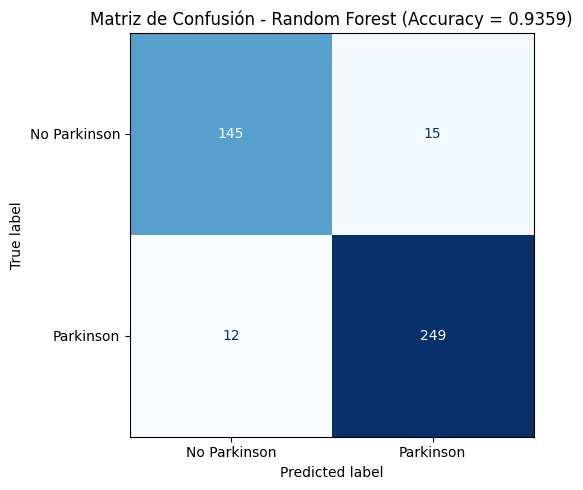

In [10]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Parkinson', 'Parkinson'])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title(f'Matriz de Confusión - Random Forest (Accuracy = {accuracy:.4f})')
plt.tight_layout()
plt.show()


## 9. Importancia de las variables (Feature Importance)

/tmp/ipykernel_615/2098541016.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette='viridis')


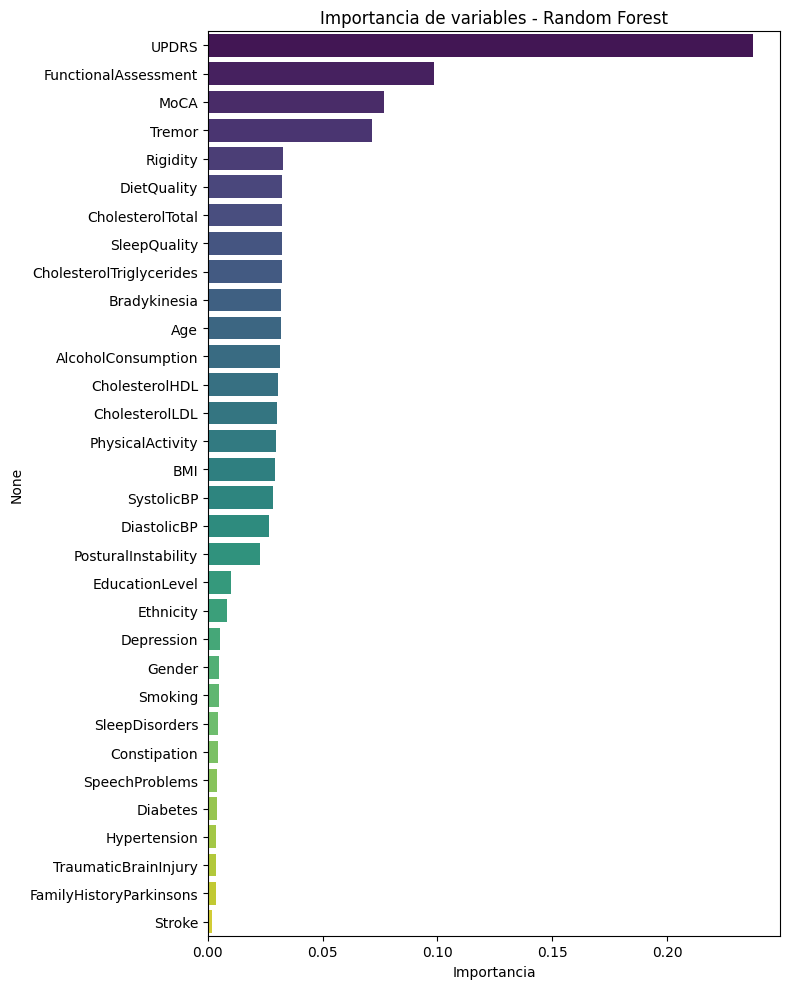

Top 10 variables más importantes:
UPDRS                       0.237359
FunctionalAssessment        0.098284
MoCA                        0.076556
Tremor                      0.071445
Rigidity                    0.032717
DietQuality                 0.032418
CholesterolTotal            0.032249
SleepQuality                0.032202
CholesterolTriglycerides    0.032179
Bradykinesia                0.032028
dtype: float64


In [11]:
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 10))
sns.barplot(x=importances.values, y=importances.index, palette='viridis')
plt.title('Importancia de variables - Random Forest')
plt.xlabel('Importancia')
plt.tight_layout()
plt.show()

print("Top 10 variables más importantes:")
print(importances.head(10))


## 10. Comparación con otros clasificadores de sklearn

Siguiendo el ejemplo de referencia
([plot_classifier_comparison](https://scikit-learn.org/stable/auto_examples/classification/plot_classifier_comparison.html)),
se entrenan además otros clasificadores comunes para comparar su accuracy contra Random Forest.


In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

classifiers = {
    'Regresión Logística': LogisticRegression(max_iter=1000, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'SVM (RBF)': SVC(kernel='rbf', random_state=42),
    'Árbol de Decisión': DecisionTreeClassifier(random_state=42),
    'Naive Bayes': GaussianNB(),
    'Random Forest': rf_model,  # ya entrenado arriba
}

results = {}

for name, clf in classifiers.items():
    if name != 'Random Forest':
        clf.fit(X_train_scaled, y_train)
        preds = clf.predict(X_test_scaled)
    else:
        preds = clf.predict(X_test)  # RF ya entrenado con datos sin escalar
    acc = accuracy_score(y_test, preds)
    results[name] = acc

results_df = pd.Series(results).sort_values(ascending=False).rename('Accuracy')
print(results_df)


Random Forest          0.935867
Árbol de Decisión      0.866983
SVM (RBF)              0.840855
Regresión Logística    0.805226
Naive Bayes            0.786223
KNN                    0.710214
Name: Accuracy, dtype: float64


/tmp/ipykernel_615/912158284.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df.values, y=results_df.index, palette='mako')


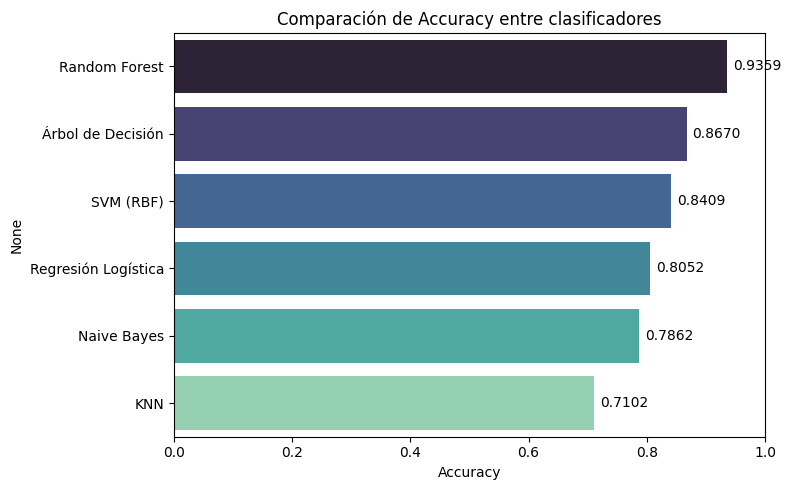

In [13]:
plt.figure(figsize=(8, 5))
sns.barplot(x=results_df.values, y=results_df.index, palette='mako')
plt.xlabel('Accuracy')
plt.title('Comparación de Accuracy entre clasificadores')
plt.xlim(0, 1)
for i, v in enumerate(results_df.values):
    plt.text(v + 0.01, i, f'{v:.4f}', va='center')
plt.tight_layout()
plt.show()


## 11. Conclusión

El modelo **Random Forest** entrenado con las 32 variables clínicas (`Age` → `Constipation`) logra
predecir el diagnóstico de Parkinson (`Diagnosis`) sobre el conjunto de prueba con el accuracy reportado
en la sección 7. La sección de importancia de variables ayuda a identificar qué características clínicas
aportan más información al modelo, y la comparación final muestra cómo se posiciona Random Forest frente
a otros clasificadores clásicos de `scikit-learn`.
